In [ ]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# CELL 2: PORTFOLIO DEFINITION & DATA COLLECTION
# ============================================================

tickers = ['SPY', 'AGG', 'GLD', 'QQQ']
weights_dict = {'SPY': 0.40, 'AGG': 0.30, 'GLD': 0.20, 'QQQ': 0.10}

start_date = '2021-06-21'
end_date = '2026-06-21'

try:
    prices = yf.download(tickers, start=start_date, end=end_date)['Close']
    prices = prices.dropna()
    if prices.empty:
        raise ValueError("No price data returned — check tickers or date range.")
except Exception as e:
    print(f"Data download failed: {e}")
    raise

# Align weights to the (alphabetically sorted) column order yfinance returns
weights = np.array([weights_dict[t] for t in prices.columns])

print(f"Portfolio: {dict(zip(prices.columns, weights))}")
print(f"Data range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Total trading days: {len(prices)}")
prices.head()

/tmp/ipykernel_13903/1484918296.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed

Portfolio: {'AGG': np.float64(0.3), 'GLD': np.float64(0.2), 'QQQ': np.float64(0.1), 'SPY': np.float64(0.4)}
Data range: 2021-06-21 to 2026-06-18
Total trading days: 1255


Ticker,AGG,GLD,QQQ,SPY
Date,,,,
2021-06-21,98.267784,166.949997,334.564972,393.348663
2021-06-22,98.370338,166.250000,337.683716,395.451630
2021-06-23,98.319061,166.139999,337.848877,394.974976
2021-06-24,98.353233,166.039993,339.937683,397.311554
2021-06-25,98.156693,166.589996,339.519897,398.722839


In [ ]:
# ============================================================
# CELL 3: RETURNS ENGINE
# ============================================================

# Log returns (time-additive, preferred for risk modelling)
asset_returns = np.log(prices / prices.shift(1)).dropna()

# Weighted portfolio return series
portfolio_returns = asset_returns @ weights
portfolio_returns.name = 'Portfolio Return'

print(f"Mean daily return: {portfolio_returns.mean():.4%}")
print(f"Daily volatility:  {portfolio_returns.std():.4%}")
print(f"Annualized volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")

portfolio_returns.head()

Mean daily return: 0.0404%
Daily volatility:  0.6861%
Annualized volatility: 10.89%


,Portfolio Return
Date,
2021-06-22,0.002533
2021-06-23,-0.000722
2021-06-24,0.002960
2021-06-25,0.001357
2021-06-28,0.002863


In [ ]:
# ============================================================
# CELL 4: HISTORICAL SIMULATION VaR & ES
# ============================================================

def historical_var_es(returns, confidence_level):
    """
    Computes VaR and Expected Shortfall via Historical Simulation.
    Returns positive numbers representing the loss magnitude.
    """
    alpha = 1 - confidence_level
    var = -np.percentile(returns, alpha * 100)
    es = -returns[returns <= -var].mean()
    return var, es

confidence_levels = [0.95, 0.99]
results_hist = {}

print("=== Historical Simulation ===")
for cl in confidence_levels:
    var, es = historical_var_es(portfolio_returns, cl)
    results_hist[cl] = {'VaR': var, 'ES': es}
    print(f"{int(cl*100)}% VaR: {var:.4%}  |  {int(cl*100)}% ES: {es:.4%}")

=== Historical Simulation ===
95% VaR: 1.0864%  |  95% ES: 1.5865%
99% VaR: 1.8993%  |  99% ES: 2.4146%


In [ ]:
# ============================================================
# CELL 5: PARAMETRIC (VARIANCE-COVARIANCE) VaR & ES
# ============================================================

def parametric_var_es(returns, confidence_level):
    """
    Computes VaR and Expected Shortfall assuming Normally distributed returns.
    """
    mu = returns.mean()
    sigma = returns.std()
    alpha = 1 - confidence_level
    z = stats.norm.ppf(alpha)
    var = -(mu + z * sigma)
    es = -(mu - sigma * stats.norm.pdf(z) / alpha)
    return var, es

results_param = {}

print("=== Parametric (Normal) ===")
for cl in confidence_levels:
    var, es = parametric_var_es(portfolio_returns, cl)
    results_param[cl] = {'VaR': var, 'ES': es}
    print(f"{int(cl*100)}% VaR: {var:.4%}  |  {int(cl*100)}% ES: {es:.4%}")

=== Parametric (Normal) ===
95% VaR: 1.0882%  |  95% ES: 1.3750%
99% VaR: 1.5558%  |  99% ES: 1.7884%


In [ ]:
# ============================================================
# CELL 6: MONTE CARLO VaR & ES
# ============================================================

def monte_carlo_var_es(returns, confidence_level, n_simulations=10000, seed=42):
    """
    Computes VaR and Expected Shortfall via Monte Carlo simulation,
    drawing from a Normal distribution fitted to historical mean/std.
    """
    rng = np.random.default_rng(seed)
    mu, sigma = returns.mean(), returns.std()
    simulated = rng.normal(mu, sigma, n_simulations)
    alpha = 1 - confidence_level
    var = -np.percentile(simulated, alpha * 100)
    es = -simulated[simulated <= -var].mean()
    return var, es, simulated

results_mc = {}
mc_simulated = None

print("=== Monte Carlo ===")
for cl in confidence_levels:
    var, es, sim = monte_carlo_var_es(portfolio_returns, cl)
    results_mc[cl] = {'VaR': var, 'ES': es}
    if cl == 0.95:
        mc_simulated = sim  # keep for visualization later
    print(f"{int(cl*100)}% VaR: {var:.4%}  |  {int(cl*100)}% ES: {es:.4%}")

=== Monte Carlo ===
95% VaR: 1.1083%  |  95% ES: 1.3953%
99% VaR: 1.5884%  |  99% ES: 1.8293%


In [ ]:
# ============================================================
# CELL 7: BACKTESTING — KUPIEC PROPORTION OF FAILURES TEST
# ============================================================

def kupiec_test(returns, var_estimate, confidence_level):
    """
    Backtests a VaR estimate by counting breaches and running the
    Kupiec (1995) likelihood-ratio test for correct breach frequency.
    """
    alpha = 1 - confidence_level
    breaches = returns < -var_estimate
    n_obs = len(returns)
    n_breaches = breaches.sum()
    breach_rate = n_breaches / n_obs

    # Guard against edge cases (zero breaches) which break the log calculation
    if n_breaches == 0 or n_breaches == n_obs:
        lr_stat = np.nan
    else:
        lr_stat = -2 * np.log(
            ((1 - alpha) ** (n_obs - n_breaches) * alpha ** n_breaches) /
            ((1 - breach_rate) ** (n_obs - n_breaches) * breach_rate ** n_breaches)
        )

    critical_value = stats.chi2.ppf(0.95, df=1)  # ~3.84
    passes = lr_stat < critical_value if not np.isnan(lr_stat) else None

    return {
        'n_obs': n_obs,
        'n_breaches': n_breaches,
        'breach_rate': breach_rate,
        'expected_rate': alpha,
        'lr_statistic': lr_stat,
        'critical_value': critical_value,
        'model_passes': passes,
        'breach_mask': breaches
    }

var_95_hist = results_hist[0.95]['VaR']
backtest_result = kupiec_test(portfolio_returns, var_95_hist, 0.95)

print("=== Kupiec Backtest (95% Historical VaR) ===")
print(f"Observations: {backtest_result['n_obs']}")
print(f"Breaches: {backtest_result['n_breaches']}")
print(f"Breach rate: {backtest_result['breach_rate']:.2%} (expected: {backtest_result['expected_rate']:.2%})")
print(f"Kupiec LR statistic: {backtest_result['lr_statistic']:.4f} (critical value: {backtest_result['critical_value']:.4f})")
print(f"Model passes backtest: {backtest_result['model_passes']}")

=== Kupiec Backtest (95% Historical VaR) ===
Observations: 1254
Breaches: 63
Breach rate: 5.02% (expected: 5.00%)
Kupiec LR statistic: 0.0015 (critical value: 3.8415)
Model passes backtest: True


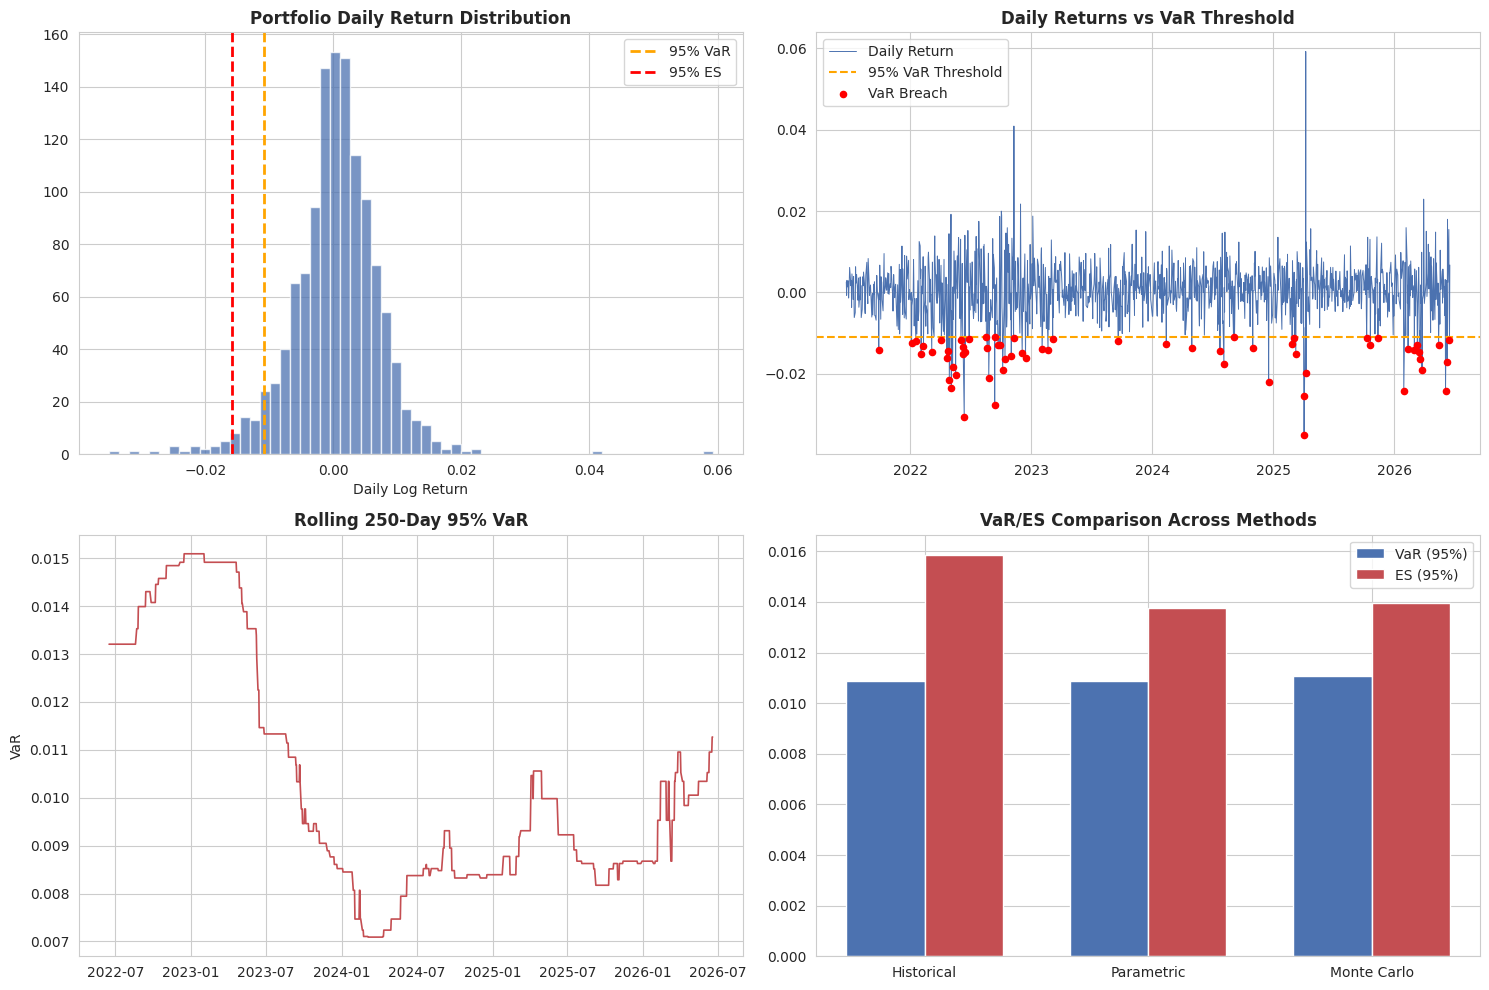


Chart saved as 'var_es_dashboard.png' — download via the Colab file browser.


In [ ]:
# ============================================================
# CELL 8: VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Chart 1: Return distribution with VaR/ES ---
axes[0, 0].hist(portfolio_returns, bins=60, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[0, 0].axvline(-results_hist[0.95]['VaR'], color='orange', linestyle='--', linewidth=2, label='95% VaR')
axes[0, 0].axvline(-results_hist[0.95]['ES'], color='red', linestyle='--', linewidth=2, label='95% ES')
axes[0, 0].set_title('Portfolio Daily Return Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Daily Log Return')
axes[0, 0].legend()

# --- Chart 2: Returns over time with breaches flagged ---
axes[0, 1].plot(portfolio_returns.index, portfolio_returns, color='#4C72B0', linewidth=0.7, label='Daily Return')
axes[0, 1].axhline(-var_95_hist, color='orange', linestyle='--', linewidth=1.5, label='95% VaR Threshold')
breach_dates = portfolio_returns[backtest_result['breach_mask']]
axes[0, 1].scatter(breach_dates.index, breach_dates, color='red', s=20, zorder=5, label='VaR Breach')
axes[0, 1].set_title('Daily Returns vs VaR Threshold', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# --- Chart 3: Rolling 95% Historical VaR (250-day window) ---
rolling_var = portfolio_returns.rolling(250).apply(lambda x: -np.percentile(x, 5))
axes[1, 0].plot(rolling_var.index, rolling_var, color='#C44E52', linewidth=1.2)
axes[1, 0].set_title('Rolling 250-Day 95% VaR', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('VaR')

# --- Chart 4: Method comparison bar chart ---
methods = ['Historical', 'Parametric', 'Monte Carlo']
var_95_values = [results_hist[0.95]['VaR'], results_param[0.95]['VaR'], results_mc[0.95]['VaR']]
es_95_values = [results_hist[0.95]['ES'], results_param[0.95]['ES'], results_mc[0.95]['ES']]

x = np.arange(len(methods))
width = 0.35
axes[1, 1].bar(x - width/2, var_95_values, width, label='VaR (95%)', color='#4C72B0')
axes[1, 1].bar(x + width/2, es_95_values, width, label='ES (95%)', color='#C44E52')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(methods)
axes[1, 1].set_title('VaR/ES Comparison Across Methods', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('var_es_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'var_es_dashboard.png' — download via the Colab file browser.")

In [ ]:
# ============================================================
# CELL 9: SUMMARY RISK REPORT
# ============================================================

report_rows = []
for cl in confidence_levels:
    report_rows.append({
        'Confidence Level': f'{int(cl*100)}%',
        'Historical VaR': f"{results_hist[cl]['VaR']:.4%}",
        'Historical ES': f"{results_hist[cl]['ES']:.4%}",
        'Parametric VaR': f"{results_param[cl]['VaR']:.4%}",
        'Parametric ES': f"{results_param[cl]['ES']:.4%}",
        'Monte Carlo VaR': f"{results_mc[cl]['VaR']:.4%}",
        'Monte Carlo ES': f"{results_mc[cl]['ES']:.4%}",
    })

report_df = pd.DataFrame(report_rows)
print("=" * 80)
print("PORTFOLIO RISK REPORT")
print(f"Portfolio: {dict(zip(prices.columns, weights))}")
print(f"Period: {portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")
print("=" * 80)
report_df

PORTFOLIO RISK REPORT
Portfolio: {'AGG': np.float64(0.3), 'GLD': np.float64(0.2), 'QQQ': np.float64(0.1), 'SPY': np.float64(0.4)}
Period: 2021-06-22 to 2026-06-18


,Confidence Level,Historical VaR,Historical ES,Parametric VaR,Parametric ES,Monte Carlo VaR,Monte Carlo ES
0,95%,1.0864%,1.5865%,1.0882%,1.3750%,1.1083%,1.3953%
1,99%,1.8993%,2.4146%,1.5558%,1.7884%,1.5884%,1.8293%
